In [1]:
# Imports
import os
import cv2
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.model_selection import train_test_split
from PIL import Image, ImageFile

import pandas as pd
import numpy as np

In [2]:
# Config
DATA_DIR = '../data/sample'
LABELS_CSV = os.path.join(DATA_DIR, 'sample_labels.csv')
IMAGE_DIR = os.path.join(DATA_DIR, 'images')
CHECKPOINT_DIR = '../checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

CLASS_LIST = [
    "Atelectasis",
    "Cardiomegaly",
    "Effusion",
    "Infiltration",
    "Mass",
    "Nodule",
    "Pneumonia",
    "Pneumothorax",
    "Consolidation",
    "Edema",
    "Emphysema",
    "Fibrosis",
    "Pleural_Thickening",
    "Hernia"
]

TOP_CLASSES = [
    "Atelectasis",
    "Effusion",
    "Infiltration",
]

BATCH_SIZE  = 16
NUM_EPOCHS = 10
VAL_SPLIT = 0.2
IMAGE_SIZE = 224
MODEL_NAME= "all_classes"

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

USE_TOP_CLASSES = False

ImageFile.LOAD_TRUNCATED_IMAGES = True


Using device: cuda


In [ ]:
# Micilaneous Functions
# CLAHE + Transformations

def apply_clahe(image): 
    image = np.array(image.convert('L'))
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    image = clahe.apply(image)
    image = Image.fromarray(image).convert('RGB')
    return image

def apply_transformations(type):
    transformation_list = [transforms.Resize((IMAGE_SIZE, IMAGE_SIZE))]
    if type == 'train':
        transformation_list.append(transforms.RandomHorizontalFlip())
    transformation_list.extend([
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )    
    ])
    return transforms.Compose(transformation_list)

In [ ]:
# X-Ray Dataset Object

class ChestXRayDataset(Dataset):
    def __init__(self, dataframe, image_dir, class_list, transform=None):
        self.df = dataframe
        self.image_dir = image_dir
        self.class_list = class_list
        self.class_to_index = {
            cls_name: idx for idx, cls_name in enumerate(class_list)
        }
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row   = self.df.iloc[index]
        image = Image.open(os.path.join(self.image_dir, row['Image Index']))
        image = apply_clahe(image)
        if self.transform:
            image = self.transform(image)

        raw_labels = row['Finding Labels']
        label = torch.zeros(len(self.class_list), dtype=torch.float32)

        if pd.notna(raw_labels) and raw_labels != "No Finding":
            for cls in str(raw_labels).split('|'):
                if cls in self.class_to_index:
                    label[self.class_to_index[cls]] = 1.0

        return image, label


In [ ]:
# Dataset Loading
# Train/val/test split + Loaders


df = pd.read_csv(LABELS_CSV)

def is_id_image(label_str):
    labels = set(label_str.split('|'))
    
    if "No Finding" in labels:
        return True
    
    return labels.issubset(TOP_CLASSES)

filtered_df = df[df["Finding Labels"].apply(is_id_image)].reset_index(drop=True)

# mask = df["Finding Labels"].apply(is_id_image)

# print("Total images:", len(df))
# print("ID-only images:", mask.sum())
# print("Removed (OOD/contaminated):", len(df) - mask.sum())

if USE_TOP_CLASSES:
    cur_df = filtered_df
    cur_classes = TOP_CLASSES
else:
    cur_df = df
    cur_classes = CLASS_LIST

NUM_CLASSES = len(cur_classes)

train_val_df, test_df = train_test_split(cur_df, test_size=0.1, random_state=42)
train_df, val_df = train_test_split(train_val_df, test_size=VAL_SPLIT, random_state=42)

train_dataset = ChestXRayDataset(
    dataframe=train_df,
    image_dir=IMAGE_DIR,
    class_list=cur_classes,
    transform=apply_transformations('train')
)

val_dataset = ChestXRayDataset(
    dataframe=val_df,
    image_dir=IMAGE_DIR,
    class_list=cur_classes,
    transform=apply_transformations('val')
)

test_dataset = ChestXRayDataset(
    dataframe=test_df,
    image_dir=IMAGE_DIR,
    class_list=cur_classes,
    transform=apply_transformations('test')
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}')


Train batches: 253 | Val batches: 64 | Test batches: 36


In [ ]:
# Model Training

RUN_CELL = False
from train_model import DenseNet121, train_model

if RUN_CELL:

    model = DenseNet121(num_classes=NUM_CLASSES)

    train_model(model, NUM_EPOCHS, train_loader, val_loader, device=DEVICE, model_name=MODEL_NAME)

In [ ]:
# Model Evaluation
# Loads checkpoint and runs per class AUROC

from evaluation import compute_AUCs

CKPT_PATH = "models/best_model_all_classes.pt"

gt = torch.FloatTensor()
gt = gt.cuda()
pred = torch.FloatTensor()
pred = pred.cuda()

loaded_model = DenseNet121(NUM_CLASSES).cuda()

if os.path.isfile(CKPT_PATH):
    print("=> loading checkpoint")
    checkpoint = torch.load(CKPT_PATH)
    loaded_model.load_state_dict(checkpoint)
    print("=> loaded checkpoint")
else:
    print("=> no checkpoint found")

# switch to evaluate mode
loaded_model.eval()

preds = []
gts = []

with torch.no_grad():
    for inp, target in test_loader:
        output = loaded_model(inp.cuda())

        preds.append(output.cpu())
        gts.append(target)

pred = torch.cat(preds, dim=0)
gt = torch.cat(gts, dim=0)

AUROCs = compute_AUCs(gt, pred, num_classes=NUM_CLASSES)
AUROC_avg = np.array(AUROCs).mean()
print('The average AUROC is {AUROC_avg:.3f}'.format(AUROC_avg=AUROC_avg))
for i in range(NUM_CLASSES):
    print('The AUROC of {} is {}'.format(cur_classes[i], AUROCs[i]))


c:\Users\Matthias\Desktop\RUG_EVERYTHING\YEAR_3\UML\Out-of-Distribution-Detection\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Matthias\Desktop\RUG_EVERYTHING\YEAR_3\UML\Out-of-Distribution-Detection\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


=> loading checkpoint
=> loaded checkpoint


C:\Users\Matthias\AppData\Local\Temp\ipykernel_26032\1967415465.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(CKPT_PATH)


The average AUROC is 0.723
The AUROC of Atelectasis is 0.7388262322472848
The AUROC of Cardiomegaly is 0.5878870673952641
The AUROC of Effusion is 0.8442448436460412
The AUROC of Infiltration is 0.6410314820720762
The AUROC of Mass is 0.6705175600739373
The AUROC of Nodule is 0.6315661871666397
The AUROC of Pneumonia is 0.7573491490458999
The AUROC of Pneumothorax is 0.7435674082015545
The AUROC of Consolidation is 0.8006303539679974
The AUROC of Edema is 0.8628859972810254
The AUROC of Emphysema is 0.7456485120718697
The AUROC of Fibrosis is 0.711257720381808
The AUROC of Pleural_Thickening is 0.724793388429752
The AUROC of Hernia is 0.6571428571428571


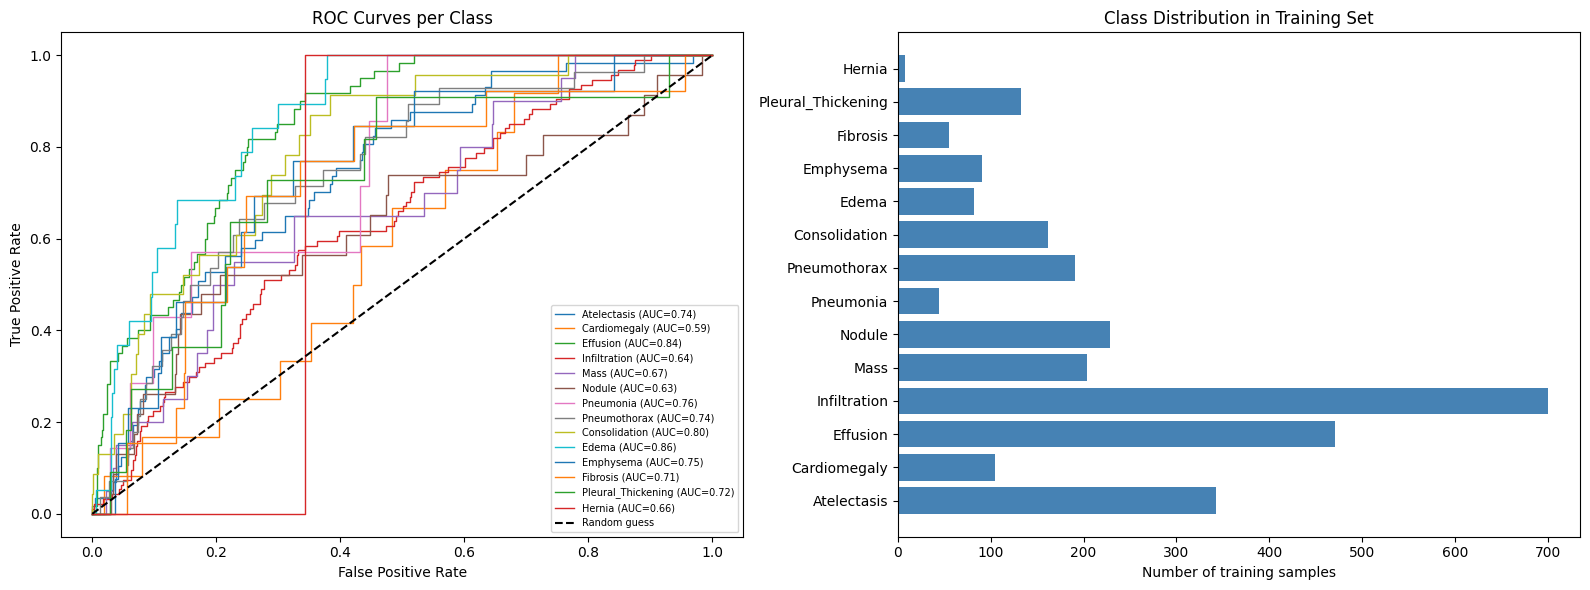

In [25]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- ROC curves ---
ax = axes[0]
for i, cls in enumerate(cur_classes):
    fpr, tpr, _ = roc_curve(gt[:, i].cpu(), pred[:, i].cpu())
    ax.plot(fpr, tpr, lw=1, label=f'{cls} (AUC={AUROCs[i]:.2f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves per Class')
ax.legend(fontsize=7, loc='lower right')

# --- Class distribution ---
ax = axes[1]
counts = []
for cls in cur_classes:
    count = train_df['Finding Labels'].str.contains(cls, na=False).sum()
    counts.append(count)

ax.barh(cur_classes, counts, color='steelblue')
ax.set_xlabel('Number of training samples')
ax.set_title('Class Distribution in Training Set')

plt.tight_layout()
plt.show()

In [ ]:
# OOD Detection Dataset Object
# The Bone Fracture dataset

from torch.utils.data import ConcatDataset
import glob

class OODDetectionDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.df = dataframe
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row   = self.df.iloc[index]
        image = Image.open(os.path.join(self.image_dir, row['Image Index']))
        image = apply_clahe(image)
        if self.transform:
            image = self.transform(image)

        label = torch.tensor(row["ood_label"], dtype=torch.float32)


        return image, label

OOD_ROOT = '../data/test'

ood_paths = []
for sub in ['fractured', 'not fractured']:
    for ext in ('*.png', '*.jpg'):
        for p in glob.glob(os.path.join(OOD_ROOT, sub, ext)):
            ood_paths.append(os.path.relpath(p, OOD_ROOT).replace('\\', '/'))

ood_df = pd.DataFrame({'Image Index': ood_paths})

id_df = test_df
id_df["ood_label"] = 0 # In-Distribution
ood_df["ood_label"] = 1 # Out-of-Distribution

id_dataset = OODDetectionDataset(
    dataframe=id_df,
    image_dir=IMAGE_DIR,
    transform=apply_transformations('test')
)

ood_dataset = OODDetectionDataset(
    dataframe=ood_df,
    image_dir=OOD_ROOT,
    transform=apply_transformations('test')
)

ood_detection_dataset = ConcatDataset([id_dataset, ood_dataset])

ood_dataset_loader = DataLoader(ood_detection_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

In [ ]:
# ENtropy Thresholds
# Calculate entropy and compare ID samples to OOD samples to set a threshold


def entropy_score(probs, eps=1e-8):
    probs = torch.clamp(probs, eps, 1 - eps)
    
    entropy = -(probs * torch.log(probs) + (1 - probs) * torch.log(1 - probs))
    return entropy.mean(dim=1)


id_scores = []

loaded_model.eval()
with torch.no_grad():
    for x, _ in val_loader:
        probs = torch.sigmoid(loaded_model(x.cuda()))
        id_scores.append(entropy_score(probs).cpu())

id_scores = torch.cat(id_scores)

THRESHOLD = torch.quantile(id_scores, 0.95)

print(THRESHOLD)

tensor(0.2991)


In [ ]:
# Entropy Classification 
# Perform binary classification based on the threshold

y_pred = []
y_true = []
y_score = []                         

loaded_model.eval()

with torch.no_grad():
    for x, y in ood_dataset_loader:
        x = x.cuda()

        logits = loaded_model(x)
        probs = torch.sigmoid(logits)

        score = entropy_score(probs)

        prediction = (score > THRESHOLD).int()

        y_pred.append(prediction)
        y_true.append(y)
        y_score.append(score.cpu())  

predictions = torch.cat(y_pred)
labels = torch.cat(y_true)
scores = torch.cat(y_score)          

print("mean entropy  ID  (chest)    :", scores[labels == 0].mean().item())
print("mean entropy  OOD (fracture) :", scores[labels == 1].mean().item())

mean entropy  ID  (chest)    : 0.1597427874803543
mean entropy  OOD (fracture) : 0.13366074860095978


In [ ]:
# Get AUROC of final results

from sklearn.metrics import roc_auc_score

auc = roc_auc_score(labels.cpu().numpy(), predictions.cpu().numpy())
print("OOD AUROC:", auc)


OOD AUROC: 0.4803921568627451


In [ ]:
# kNN OOD Feature-based Detection
# Uses FAISS (Facebook AI similarity search). Efficent for similarity search and clustering

import torch
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import roc_auc_score
import faiss

@torch.no_grad()
def extract_features(model, dataloader):
    features = []
    labels = []
    
    model.eval()
    for data, label in dataloader:
        x = model.densenet121.features(data.cuda())
        x = F.relu(x, inplace=True)
        x = F.adaptive_avg_pool2d(x, (1, 1))
        x = x.squeeze()
        x = F.normalize(x, p=2, dim=-1)
        
        features.append(x.cpu().numpy())
        labels.append(label.numpy())

    return np.vstack(features).astype(np.float32), np.concatenate(labels)

train_features, _ = extract_features(loaded_model, train_loader)
test_features, test_labels = extract_features(loaded_model, ood_dataset_loader)

index = faiss.IndexFlatL2(train_features.shape[1])
index.add(train_features)

k = 50
distances, indices = index.search(test_features, k)

out_scores = distances[:, -1]

auc = roc_auc_score(test_labels, out_scores)
print(f"kNN OOD AUROC: {auc:.3f}")

kNN OOD AUROC: 0.995


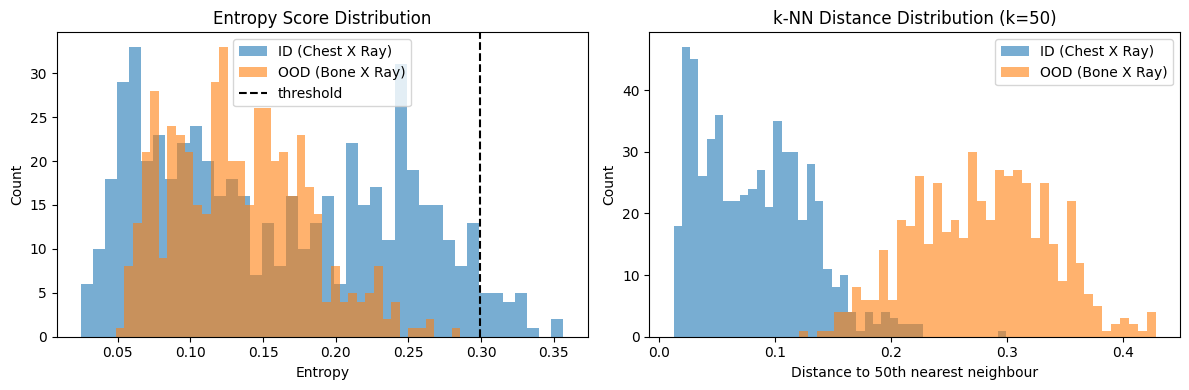

In [ ]:
# Historgrams
# Compares OOD Score distribution

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Entropy Plot
ax = axes[0]
ax.hist(scores[labels == 0].numpy(), bins=40, alpha=0.6, label='ID (Chest X Ray)')
ax.hist(scores[labels == 1].numpy(), bins=40, alpha=0.6, label='OOD (Bone X Ray)')
ax.axvline(THRESHOLD.item(), color='black', linestyle='--', label='threshold')
ax.set_title('Entropy Score Distribution')
ax.set_xlabel('Entropy')
ax.set_ylabel('Count')
ax.legend()

# KNN Plot
ax = axes[1]
ax.hist(out_scores[test_labels == 0], bins=40, alpha=0.6, label='ID (Chest X Ray)')
ax.hist(out_scores[test_labels == 1], bins=40, alpha=0.6, label='OOD (Bone X Ray)')
ax.set_title('k-NN Distance Distribution (k=50)')
ax.set_xlabel('Distance to 50th nearest neighbour')
ax.set_ylabel('Count')
ax.legend()

plt.tight_layout()
plt.show()